# Modeling of Data (Curve Fitting)

Given a set of observations, one often wishes to condense and summarize the data by fitting it to a "model" that depends on adjustable parameters. Sometimes the model is simply a convenient class of functions, such as polynomials or Gaussians, and the fit supplies a smoothed representation of the data. Other times, the model represents an underlying physical theory, and the parameters have profound physical significance. In either case, fitting data to a curve is not a black art, though many practitioners treat it as such. In this chapter, we develop the statistical framework of maximum likelihood, explore the computational bedrock of Singular Value Decomposition for linear models, derive the Levenberg-Marquardt algorithm for non-linear models, and discuss the pitfalls of robust estimation.



## 1. Introduction: The Philosophy of the Fit

I have spent a significant amount of time to convince students and colleagues that "fitting a curve" is not merely a matter of invoking a black-box routine and accepting the output. An experimenter or observer who gathers data without a deep understanding of the numerical machinery used to model it is navigating a ship without a compass.

We are generally given a set of $N$ data points $(x_i, y_i)$, where $i = 1, \dots, N$. The independent variable $x_i$ might be time, frequency, or spatial coordinate. The dependent variable $y_i$ is the measured quantity. We propose a model $y(x; a_1, \dots, a_M)$ that depends on $M$ adjustable parameters $a_j$. The fundamental goal is to find the parameters $a_j$ that give the "best" fit of the model to the data.

But what do we mean by "best"? If you do not define this mathematically, you are not doing science. The definition of "best" depends intimately on the statistical nature of the measurement errors.

## 2. Maximum Likelihood and Least Squares

Let us assume that each data point $y_i$ has a measurement error that is independently random and distributed as a Gaussian (normal) distribution around the "true" model $y(x_i; \mathbf{a})$. Let the standard deviation of this normal distribution be $\sigma_i$.

The probability of the data set given a particular set of parameters $\mathbf{a}$ is the product of the probabilities of each individual measurement:

$$P(\{y_k\}^M|\mathbf{a}) \propto \prod_{i=1}^{N} \left\{ \exp\left[ -\frac{1}{2} \left( \frac{y_i - y(x_i; \mathbf{a})}{\sigma_i} \right)^2 \right] \Delta y \right\}$$

where $\Delta y$ is a small interval. It is instructive to view this from a Bayesian perspective. Bayes' theorem relates the posterior probability of the parameters given the data, $P(\mathbf{a}|\{y_k\})$, to the likelihood of the data given the parameters, $P(\{y_k\}|\mathbf{a})$, and the prior probability of the parameters, $P(\mathbf{a})$:

$$P(\mathbf{a}|\{y_k\}) \propto P(\{y_k\}|\mathbf{a}) P(\mathbf{a})$$

If we assume a uniform, uninformative prior—meaning we have no initial prejudice about the values of $\mathbf{a}$, so $P(\mathbf{a})$ is a constant—then the posterior probability $P(\mathbf{a}|\{y_k\})$ becomes directly proportional to the likelihood function $P(\{y_k\}|\mathbf{a})$ we defined above. Therefore, finding the parameters that maximize the posterior probability (known as the Maximum A Posteriori or MAP estimate) is mathematically equivalent to finding the parameters that maximize the likelihood. The method of maximum likelihood thus tells us that the "best" parameters are those that maximize this probability. Maximizing $P$ is identical to maximizing its logarithm, or equivalently, minimizing the negative of its logarithm. Taking the negative logarithm, we find we need to minimize the quantity we famously call $\chi^2$ (chi-square):

$$\chi^2 \equiv \sum_{i=1}^{N} \left( \frac{y_i - y(x_i; \mathbf{a})}{\sigma_i} \right)^2$$

This is the justification for the method of least squares. Note carefully the underlying assumptions: the errors must be Gaussian, and they must be independent. If your data contains massive outliers (which violate the Gaussian assumption), least squares will fail spectacularly. We will address this in Section 7.


### 2.1 Goodness of Fit

Before we delve into finding the minimum of $\chi^2$, we must ask: how do we know if our fit is actually any good? Just because we found a minimum doesn't mean the model reflects reality. The minimum might still be a terrible fit.

To understand why this is the case, we must look at the geometry of our fit. If the true model is correct and the measurement errors are normally distributed, each scaled residual $z_i = (y_i - y(x_i))/\sigma_i$ is a standard normal variable, drawn from $\mathcal{N}(0, 1)$. The sum of the squares of $N$ independent standard normal variables inherently follows a chi-square distribution with $N$ degrees of freedom.

However, we are not just summing random variables; we have minimized this sum with respect to $M$ parameters. By enforcing the $M$ normal equations ($\nabla_{\mathbf{a}} \chi^2 = \mathbf{0}$), we impose $M$ linear constraints on our residuals. Geometrically, the $N$-dimensional vector of residuals is projected onto an orthogonal subspace of dimension $\nu = N - M$. Therefore, **the minimized $\chi^2$ sum is constrained to this subspace and is thus drawn from a chi-square distribution with exactly $\nu = N - M$ degrees of freedom.**

The probability density function **(PDF) for a chi-square distribution with $\nu$ degrees of freedom** is:

$$p(z) = \frac{1}{2^{\nu/2}\Gamma(\nu/2)} z^{\nu/2 - 1} e^{-z/2}$$

where $z$ represents the $\chi^2$ value. The probability $Q$ that the minimized chi-square should exceed our observed value $\chi^2_{\mathrm{obs}}$ strictly by chance (even if the model is perfectly correct) is the integral of this PDF from $\chi^2_{\mathrm{obs}}$ to infinity:

$$Q = \int_{\chi^2_{\mathrm{obs}}}^{\infty} \frac{1}{2^{\nu/2}\Gamma(\nu/2)} z^{\nu/2 - 1} e^{-z/2} dz$$

We can simplify this integral by applying the substitution $t = z/2$, which implies $dt = dz/2$:

$$Q = \frac{1}{\Gamma(\nu/2)} \int_{\chi^2_{\mathrm{obs}}/2}^{\infty} t^{\nu/2 - 1} e^{-t} dt$$

This resulting integral is the normalized upper incomplete gamma function, commonly denoted as $Q(a, x) = \frac{\Gamma(a,x)}{\Gamma(a)} = \frac{1}{\Gamma(a)} \int_x^{\infty} t^{a-1} e^{-t} dt$. We can rewrite the above as:

$$Q = \mathrm{gammq}\left( \frac{N-M}{2}, \frac{\chi^2}{2} \right)$$

**Note:** As a rule of thumb, a "good" fit has $\chi^2 \approx \nu$. If $\chi^2 \gg \nu$, your model is wrong, or your errors $\sigma_i$ are larger than you thought. If $\chi^2 \ll \nu$, you have either invented a magical model that perfectly captures the noise, or, more likely, you have overestimated your measurement errors $\sigma_i$.

## 3. Fitting Data to a Straight Line

Let us begin with the simplest possible model: $y(x) = a + bx$. Here, the parameters $\mathbf{a}$ are just the intercept $a$ and the slope $b$. The chi-square function is:

$$\chi^2(a,b) = \sum_{i=1}^{N} \left( \frac{y_i - a - bx_i}{\sigma_i} \right)^2$$

To find the minimum, we take the partial derivatives with respect to $a$ and $b$ and set them to zero:

$$\frac{\partial \chi^2}{\partial a} = -2 \sum_{i=1}^{N} \frac{y_i - a - bx_i}{\sigma_i^2} = 0$$

$$\frac{\partial \chi^2}{\partial b} = -2 \sum_{i=1}^{N} \frac{x_i(y_i - a - bx_i)}{\sigma_i^2} = 0$$

Let us define some convenient sums:

$$\begin{aligned}
S &\equiv \sum_{i=1}^{N} \frac{1}{\sigma_i^2}, \quad S_x \equiv \sum_{i=1}^{N} \frac{x_i}{\sigma_i^2}, \quad S_y \equiv \sum_{i=1}^{N} \frac{y_i}{\sigma_i^2} \\
S_{xx} &\equiv \sum_{i=1}^{N} \frac{x_i^2}{\sigma_i^2}, \quad S_{xy} \equiv \sum_{i=1}^{N} \frac{x_i y_i}{\sigma_i^2}
\end{aligned}$$

The equations then become a simple $2 \times 2$ linear system:

$$\begin{aligned}
a S + b S_x &= S_y \\
a S_x + b S_{xx} &= S_{xy}
\end{aligned}$$

Defining the determinant $\Delta \equiv S S_{xx} - (S_x)^2$, the solution is analytic and trivial:

$$a = \frac{S_{xx}S_y - S_x S_{xy}}{\Delta}, \quad b = \frac{S S_{xy} - S_x S_y}{\Delta}$$

The variances (uncertainties) in the parameters are $\sigma_a^2 = S_{xx}/\Delta$ and $\sigma_b^2 = S/\Delta$.

This looks simple, and it is. However, numerical roundoff error can destroy this calculation if the $x_i$ values are very large and very close together. It is always computationally safer to shift the origin of $x$ to the mean of the data before calculating these sums, though for simple problems modern double-precision arithmetic often masks our sins.

## 4. General Linear Least Squares

We now leap to a much more general case. Suppose the model is a linear combination of any $M$ specified functions of $x$.

$$y(x) = \sum_{k=1}^{M} a_k X_k(x)$$

The functions $X_k(x)$ are called basis functions. They could be $1, x, x^2, \dots$ (Taylor polynomials), or $\sin(kx), \cos(kx)$ (Fourier series). The crucial point is that the model is linear in the parameteers $a_k$. The functions $X_k(x)$ themselves can be wildly nonlinear.

The chi-square is:

$$\chi^2 = \sum_{i=1}^{N} \left[ \frac{y_i - \sum_{k=1}^{M} a_k X_k(x_i)}{\sigma_i} \right]^2$$

Let us define a matrix $\mathbf{A}$, known as the design matrix. It is an $N \times M$ matrix where the components are:

$$A_{ij} = \frac{X_j(x_i)}{\sigma_i}$$

We also define a vector $\mathbf{b}$ of length $N$:

$$b_i = \frac{y_i}{\sigma_i}$$

The problem of minimizing $\chi^2$ can be cast elegantly in matrix notation. We want to find the parameter vector $\mathbf{a}$ that minimizes:

$$|\mathbf{A} \cdot \mathbf{a} - \mathbf{b}|^2$$

To see how this matrix expression equates to our original summation for $\chi^2$, consider the dimensions and components. The product $\mathbf{A} \cdot \mathbf{a}$ produces a vector of length $N$ whose $i$-th component is $\sum_{k=1}^M A_{ik}a_k = \sum_{k=1}^M \frac{a_k X_k(x_i)}{\sigma_i}$. Subtracting the vector $\mathbf{b}$ (whose $i$-th component is $\frac{y_i}{\sigma_i}$) gives a new vector representing the scaled residuals. The squared norm notation $|\mathbf{v}|^2$ dictates that we square each component of this resulting vector and sum them from $i=1$ to $N$, perfectly reproducing the $\chi^2$ objective function: $\sum_{i=1}^N \left[ \frac{\sum_{k=1}^{M} a_k X_k(x_i) - y_i}{\sigma_i} \right]^2$.

Taking the derivative with respect to the components of $\mathbf{a}$ and setting them to zero yields the so-called normal equations:

$$(\mathbf{A}^T \cdot \mathbf{A}) \cdot \mathbf{a} = \mathbf{A}^T \cdot \mathbf{b}$$

where $\mathbf{A}^T$ is the transpose of $\mathbf{A}$. Let $\mathbf{C} = \mathbf{A}^T \cdot \mathbf{A}$ and $\mathbf{d} = \mathbf{A}^T \cdot \mathbf{b}$. We just need to solve the $M \times M$ linear system $\mathbf{C} \cdot \mathbf{a} = \mathbf{d}$.

### 4.1 The Peril of Normal Equations

Here is where I must raise a red flag. In many textbooks, the derivation stops here, and the student is implicitly encouraged to code up an LU decomposition to solve $\mathbf{C} \cdot \mathbf{a} = \mathbf{d}$. Do not do this unless you understand the risks.

The matrix $\mathbf{A}^T \cdot \mathbf{A}$ is very often ill-conditioned. If the basis functions $X_k(x)$ are even slightly correlated (for example, fitting a high-degree polynomial), the columns of $\mathbf{A}$ will be nearly linearly dependent.

The condition number of a matrix tells you how much errors in the data will be magnified in the solution. The fundamental tragedy of the normal equations is that the condition number of $\mathbf{A}^T \cdot \mathbf{A}$ is the square of the condition number of $\mathbf{A}$. By explicitly forming $\mathbf{A}^T \cdot \mathbf{A}$, you are squaring your susceptibility to roundoff error. In single precision, this is almost always fatal; in double precision, it will still kill you for polynomials of degree higher than 7 or 8.

### 4.2 Singular Value Decomposition (SVD)

The cure for this numerical disease is Singular Value Decomposition (SVD). SVD is not just a tool; it is a conceptual revelation about linear spaces.

Any $N \times M$ matrix $\mathbf{A}$ (with $N \ge M$) can be decomposed into the product of three matrices:

$$\mathbf{A} = \mathbf{U} \cdot \mathbf{W} \cdot \mathbf{V}^T$$

where:

$\mathbf{U}$ is an $N \times M$ column-orthogonal matrix ($\mathbf{U}^T \cdot \mathbf{U} = \mathbf{I}$).

$\mathbf{W}$ is an $M \times M$ diagonal matrix with positive or zero elements $w_i$, known as singular values.

$\mathbf{V}$ is an $M \times M$ orthogonal matrix ($\mathbf{V}^T \cdot \mathbf{V} = \mathbf{I}$).

Why is this useful? Because we can define the pseudo-inverse of $\mathbf{A}$. If $\mathbf{A}$ is a square, non-singular matrix, then $\mathbf{A}^{-1} = \mathbf{V} \cdot \mathbf{W}^{-1} \cdot \mathbf{U}^T$, where $\mathbf{W}^{-1}$ is simply a diagonal matrix with elements $1/w_i$.

In the least-squares problem, it turns out that the solution vector $\mathbf{a}$ that minimizes $|\mathbf{A} \cdot \mathbf{a} - \mathbf{b}|^2$ is given exactly by:

$$\mathbf{a} = \mathbf{V} \cdot \mathbf{W}^{-1} \cdot (\mathbf{U}^T \cdot \mathbf{b})$$

The brilliance of SVD lies in how it handles singular or near-singular situations. If the basis functions are collinear, one or more of the singular values $w_i$ will be zero (or dangerously close to zero, dominated by machine roundoff). To clarify, these are the exact same $X_k(x)$ basis functions that constitute the columns of our design matrix $\mathbf{A}$. While we might intend for our chosen basis functions to be completely independent, in practice (such as when evaluating high-degree polynomials like $x^{10}$ and $x^{11}$ over a narrow range of data), the resulting columns in $\mathbf{A}$ can be highly correlated. SVD fixes this underlying flaw. It uses $\mathbf{U}$ and $\mathbf{V}$ to construct perfectly orthogonal combinations of your data and parameters. When a singular value $w_i$ drops to zero, it is mathematical proof that some of the original basis functions in $\mathbf{A}$ were too collinear to be uniquely useful. In the normal equations, this collinearity makes the determinant zero and the inversion impossible.

With SVD, when we encounter a $w_i$ that is very small, we simply set $1/w_i = 0$ in the diagonal matrix $\mathbf{W}^{-1}$. Yes, you read that correctly: we replace infinity with zero. This sounds like mathematical heresy, but it is precisely the right thing to do.

By setting $1/w_i = 0$, we are throwing away the linear combinations of basis functions that are corrupted by noise and roundoff, and keeping only the robust, orthogonal combinations that actually describe the data. SVD automatically identifies and excises the degenerate parts of your model. I cannot stress enough: SVD is the method of choice for solving linear least squares problems.

--- Section 4: SVD vs Normal Equations ---
Condition number of A: 1.17e+08
Condition number of A^T A: 1.30e+16
Normal equations executed via explicit inversion (expect catastrophic failure!).
SVD pseudo-inverse solved robustly.

Magnitude (L2 Norm) of Normal Eq coefficients: 5.03e+05
Magnitude (L2 Norm) of SVD coefficients:       4.72e+05

Dense RMSE vs True Model (Normal Equations): 1.5772e-01
Dense RMSE vs True Model (SVD):              2.3033e-02



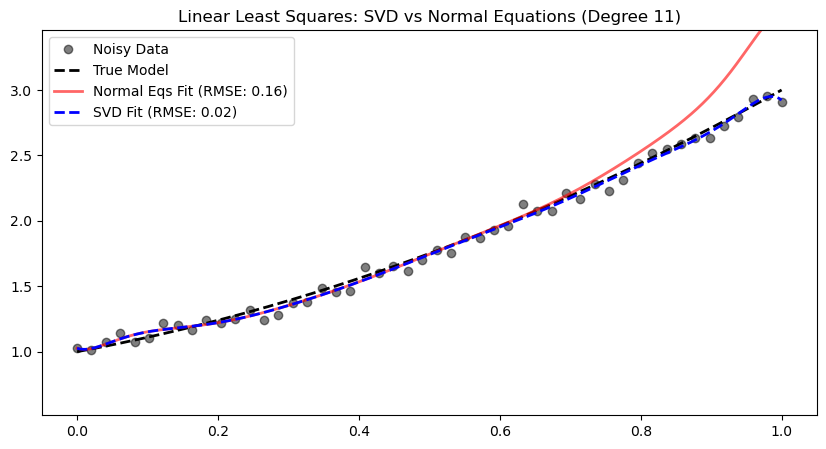

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.optimize import curve_fit

# Set random seed for reproducibility
np.random.seed(42)

def section_4_svd_vs_normal_equations():
    """
    Illustrates Section 4: The peril of Normal Equations vs the stability of SVD 
    when dealing with highly collinear basis functions (e.g., high-degree polynomials).
    """
    print("--- Section 4: SVD vs Normal Equations ---")
    
    # Generate data
    x = np.linspace(0, 1, 50)
    # True model: y = 1 + x + x^2
    y_true = 1 + x + x**2
    y = y_true + np.random.normal(0, 0.05, len(x))
    
    # Create an ill-conditioned design matrix A (Polynomial of high degree)
    # We use degree 11 to ensure A^T A thoroughly exceeds double precision limits
    degree = 11
    A = np.vander(x, degree + 1)
    
    # 1. Normal Equations (A^T * A * a = A^T * y)
    ATA = A.T @ A
    ATy = A.T @ y
    print(f"Condition number of A: {np.linalg.cond(A):.2e}")
    print(f"Condition number of A^T A: {np.linalg.cond(ATA):.2e}")
    
    try:
        # This will execute using robust LU decomposition (LAPACK), but the underlying
        # math limits mean it still produces wildly unstable coefficients
        a_normal = np.linalg.inv(ATA) @ ATy
        print("Normal equations executed via explicit inversion (expect catastrophic failure!).")
    except np.linalg.LinAlgError:
        print("Normal equations failed (Singular Matrix).")
        a_normal = np.zeros(degree + 1)

    # 2. Singular Value Decomposition (SVD)
    U, s, Vh = svd(A, full_matrices=False)
    
    # Threshold singular values based on the maximum singular value (machine precision)
    threshold = 1e-14 * np.max(s)
    s_inv = np.where(s > threshold, 1.0 / s, 0.0)
    
    # a = V * W^-1 * U^T * y
    a_svd = Vh.T @ np.diag(s_inv) @ U.T @ y
    print("SVD pseudo-inverse solved robustly.")

    # Reveal the catastrophic cancellation by looking at the magnitude of the parameters
    print(f"\nMagnitude (L2 Norm) of Normal Eq coefficients: {np.linalg.norm(a_normal):.2e}")
    print(f"Magnitude (L2 Norm) of SVD coefficients:       {np.linalg.norm(a_svd):.2e}\n")

    # To see the failure, we must evaluate the fit on a dense grid BETWEEN the data points
    x_dense = np.linspace(0, 1, 500)
    y_true_dense = 1 + x_dense + x_dense**2
    A_dense = np.vander(x_dense, degree + 1)

    # Compare accuracy (Root Mean Square Error against True Model on the dense grid)
    rmse_normal = np.sqrt(np.mean((A_dense @ a_normal - y_true_dense)**2))
    rmse_svd = np.sqrt(np.mean((A_dense @ a_svd - y_true_dense)**2))
    
    print(f"Dense RMSE vs True Model (Normal Equations): {rmse_normal:.4e}")
    print(f"Dense RMSE vs True Model (SVD):              {rmse_svd:.4e}\n")

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, 'ko', alpha=0.5, label='Noisy Data')
    plt.plot(x_dense, y_true_dense, 'k--', label='True Model', linewidth=2)
    
    # Limit y-axis so the exploded normal equation fit doesn't ruin the plot scale entirely
    plt.ylim(min(y) - 0.5, max(y) + 0.5)
    
    plt.plot(x_dense, A_dense @ a_normal, 'r-', alpha=0.6, linewidth=2, label=f'Normal Eqs Fit (RMSE: {rmse_normal:.2f})')
    plt.plot(x_dense, A_dense @ a_svd, 'b--', linewidth=2, label=f'SVD Fit (RMSE: {rmse_svd:.2f})')
    plt.title(f"Linear Least Squares: SVD vs Normal Equations (Degree {degree})")
    plt.legend(loc='upper left')
    plt.show()

section_4_svd_vs_normal_equations()

## 5. Nonlinear Models: The Levenberg-Marquardt Algorithm

We now arrive at the heart of the matter. What if our model depends nonlinearly on the parameters? For example, fitting a Gaussian profile:

$$y(x) = a_1 \exp\left[ -\left(\frac{x - a_2}{a_3}\right)^2 \right]$$

The parameter $a_1$ (amplitude) is linear, but $a_2$ (center) and $a_3$ (width) are highly non-linear. The chi-square surface is no longer a simple paraboloid; it can have valleys, ridges, and local minima. We must use an iterative procedure.

Let us expand $\chi^2(\mathbf{a})$ in a Taylor series about our current trial parameter vector $\mathbf{a}_{\mathrm{cur}}$:

$$\chi^2(\mathbf{a}) \approx \chi^2(\mathbf{a}_{\mathrm{cur}}) + \sum_{k} \frac{\partial \chi^2}{\partial a_k} \delta a_k + \frac{1}{2} \sum_{k,l} \frac{\partial^2 \chi^2}{\partial a_k \partial a_l} \delta a_k \delta a_l$$

We define the gradient vector $\beta$ and the Hessian matrix $\alpha$:

$$\beta_k \equiv -\frac{1}{2} \frac{\partial \chi^2}{\partial a_k}, \quad \alpha_{kl} \equiv \frac{1}{2} \frac{\partial^2 \chi^2}{\partial a_k \partial a_l}$$

To find the minimum of this quadratic approximation, we set the derivative with respect to $\delta \mathbf{a}$ to zero, which yields:

$$\sum_{l=1}^{M} \alpha_{kl} \delta a_l = \beta_k$$

This is a set of linear equations for the increments $\delta \mathbf{a}$ that we should add to our current parameters. This is the inverse-Hessian method. It works beautifully—if you are very close to the minimum. It also requires computation or knowledge of the derivatives of $\chi^2$ in a sizable neighborhood in the parameter space of $\mathbf{a}$ in proximity to the true \chi^2-$minimizing $\mathbf{a}_{min}$.

However, if you are far from the minimum, the quadratic approximation is poor, and taking the step $\delta \mathbf{a}$ might actually increase $\chi^2$. In this regime, we should fall back on the steepest descent method, where we take a step down the gradient:

$$\delta a_l = \mathrm{constant} \times \beta_l$$

### 5.1 The Genius of Levenberg and Marquardt

The Levenberg-Marquardt method elegantly interpolates between the inverse-Hessian method and the steepest descent method. Marquardt noticed two things. First, the constant in the steepest descent method must have dimensions of $1/\alpha_{ll}$. Second, we can transition between the two regimes by defining a new matrix $\alpha^\prime$:

$$\begin{aligned}
\alpha^\prime_{jj} &= \alpha_{jj}(1 + \lambda) \\
\alpha^\prime_{jk} &= \alpha_{jk} \quad (j \neq k)
\end{aligned}$$

where $\lambda$ is a dimensionless scaling factor.

We then solve the modified equations:

$$\sum_{l=1}^{M} \alpha^\prime_{kl} \delta a_l = \beta_k$$

Consider the limits of $\lambda$:

As $\lambda \to 0$, the matrix $\alpha^\prime \to \alpha$, and we recover the inverse-Hessian method, which converges quadratically near the minimum.

As $\lambda \to \infty$, the diagonal terms dominate. The matrix becomes diagonally dominant, and the equation uncouples to $\lambda \alpha_{kk} \delta a_k \approx \beta_k$, which is exactly the steepest descent method with a small step size.

### 5.2 Practical Implementation of L-M

The algorithm proceeds as follows:

Compute $\chi^2(\mathbf{a})$.

Pick a modest value for $\lambda$, say $\lambda = 0.001$.

Solve the linear equations $\sum \alpha^\prime_{kl} \delta a_l = \beta_k$ for $\delta \mathbf{a}$, and evaluate $\chi^2(\mathbf{a} + \delta \mathbf{a})$.

Evaluate: If $\chi^2(\mathbf{a} + \delta \mathbf{a}) \ge \chi^2(\mathbf{a})$, the step was bad. The quadratic approximation failed. Increase $\lambda$ by a factor of 10 (making it more like steepest descent) and go back to step 3.

Success: If $\chi^2(\mathbf{a} + \delta \mathbf{a}) < \chi^2(\mathbf{a})$, the step was good. Decrease $\lambda$ by a factor of 10 (moving closer to the inverse-Hessian method), update $\mathbf{a} \leftarrow \mathbf{a} + \delta \mathbf{a}$, and go to step 3.

You stop iterating when the decrease in $\chi^2$ becomes negligible (e.g., less than $10^{-3}$). The Levenberg-Marquardt algorithm has become the standard for nonlinear least squares precisely because it is incredibly robust. It smoothly transitions from the cautious approach of steepest descent when far from the solution, to the rapid, aggressive convergence of the Hessian method when approaching the minimum.



### 5.3 Computing the Hessian

There is a subtle numerical trick regarding the Hessian $\alpha_{kl}$. To see this, let us derive the true Hessian starting from the definition of $\chi^2$:

$$\chi^2 = \sum_{i=1}^{N} \left[ \frac{y_i - y(x_i)}{\sigma_i} \right]^2$$

Taking the first partial derivative with respect to a parameter $a_k$:

$$\frac{\partial \chi^2}{\partial a_k} = 2 \sum_{i=1}^{N} \left[ \frac{y_i - y(x_i)}{\sigma_i} \right] \left( -\frac{1}{\sigma_i} \frac{\partial y(x_i)}{\partial a_k} \right) = -2 \sum_{i=1}^{N} \frac{y_i - y(x_i)}{\sigma_i^2} \frac{\partial y(x_i)}{\partial a_k}$$

Now, we take the second partial derivative with respect to another parameter $a_l$, applying the product rule:

$$\frac{\partial^2 \chi^2}{\partial a_k \partial a_l} = -2 \sum_{i=1}^{N} \frac{1}{\sigma_i^2} \left[ \left(-\frac{\partial y(x_i)}{\partial a_l}\right) \frac{\partial y(x_i)}{\partial a_k} + (y_i - y(x_i)) \frac{\partial^2 y(x_i)}{\partial a_k \partial a_l} \right]$$

Recall from our quadratic expansion in Section 5 that $\alpha_{kl} \equiv \frac{1}{2} \frac{\partial^2 \chi^2}{\partial a_k \partial a_l}$. Multiplying our second derivative by $\frac{1}{2}$ and distributing the negative sign yields the true Hessian, which involves second derivatives of the model:

$$\alpha_{kl} = \sum_{i=1}^{N} \frac{1}{\sigma_i^2} \left[ \frac{\partial y(x_i)}{\partial a_k} \frac{\partial y(x_i)}{\partial a_l} - (y_i - y(x_i)) \frac{\partial^2 y(x_i)}{\partial a_k \partial a_l} \right]$$

In practice, computing the second derivative term is often computationally expensive and, more importantly, it is multiplied by $(y_i - y(x_i))$, which is essentially the residual. If the model is a good fit, these residuals are just random noise, and summing them against the second derivatives tends to average out to zero. Therefore, we almost universally drop the second derivative term and approximate the Hessian using only first derivatives:

$$\alpha_{kl} \approx \sum_{i=1}^{N} \frac{1}{\sigma_i^2} \left( \frac{\partial y(x_i)}{\partial a_k} \frac{\partial y(x_i)}{\partial a_l} \right)$$

This approximation dramatically simplifies the code and surprisingly often stabilizes the iteration, as it avoids injecting noise from the residuals back into the curvature matrix.

--- Section 5: Levenberg-Marquardt (Non-linear) ---
True parameters:      [5.0, 1.0, 1.5]
Estimated parameters: [5.09024368 1.0327488  1.4597025 ]
Uncertainties (1-sig): [0.13586491 0.03181183 0.04498891]



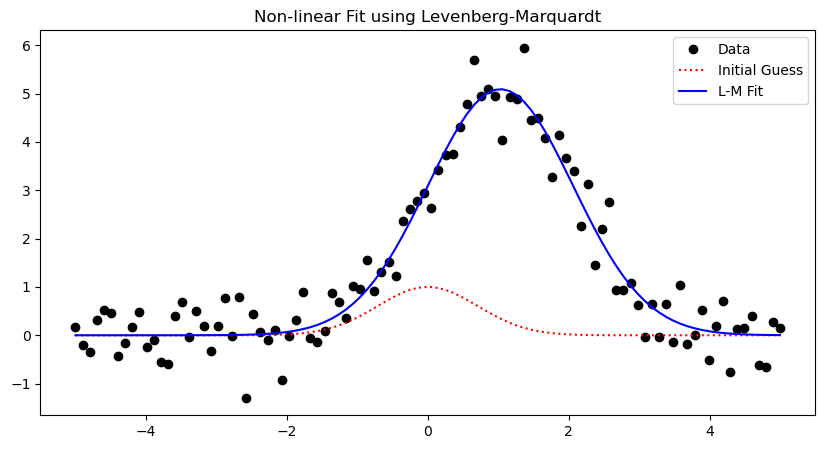

In [2]:
def section_5_levenberg_marquardt():
    """
    Illustrates Section 5: Using Levenberg-Marquardt to fit a non-linear Gaussian profile.
    """
    print("--- Section 5: Levenberg-Marquardt (Non-linear) ---")
    
    # Define the non-linear Gaussian model
    def gaussian(x, amplitude, center, width):
        return amplitude * np.exp(-((x - center) / width)**2)
    
    x = np.linspace(-5, 5, 100)
    true_params = [5.0, 1.0, 1.5] # amplitude, center, width
    y_true = gaussian(x, *true_params)
    
    # Add noise
    sigma_y = 0.5
    y = y_true + np.random.normal(0, sigma_y, len(x))
    
    # Initial guess far from the truth to test LM robustness
    initial_guess = [1.0, 0.0, 1.0]
    
    # scipy.optimize.curve_fit uses Levenberg-Marquardt ('lm') by default
    popt, pcov = curve_fit(gaussian, x, y, p0=initial_guess, method='lm')
    
    print(f"True parameters:      {true_params}")
    print(f"Estimated parameters: {popt}")
    print(f"Uncertainties (1-sig): {np.sqrt(np.diag(pcov))}\n")
    
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, 'ko', label='Data')
    plt.plot(x, gaussian(x, *initial_guess), 'r:', label='Initial Guess')
    plt.plot(x, gaussian(x, *popt), 'b-', label='L-M Fit')
    plt.title("Non-linear Fit using Levenberg-Marquardt")
    plt.legend()
    plt.show()

section_5_levenberg_marquardt()

## 6. Uncertainties on Estimated Model Parameters: The Bayesian Posterior

Suppose your Levenberg-Marquardt routine converges, and you have found the Maximum A Posteriori (MAP) parameters, $\mathbf{a}_{\mathrm{min}}$. Are you done? Absolutely not. A parameter estimate without a rigorous quantification of its uncertainty is just a naked number.

In the frequentist approach, we often talk about "confidence intervals." But in the Bayesian framework we have adopted here, we seek credible intervals. The distinction is profound: a credible interval is a region in parameter space that has a specific probability of containing the true parameters, given the data we actually observed. This is directly encapsulated by the posterior distribution, $P(\mathbf{a}|\{y_k\}) \propto \exp(-\chi^2(\mathbf{a})/2)$.

To find the error bars on $\mathbf{a}$, we must explore the shape of this posterior distribution around its peak at $\mathbf{a}_{\mathrm{min}}$.

### 6.1 The Laplace Approximation and the Covariance Matrix

If the posterior distribution is sharply peaked and well-behaved, we can approximate it locally as a multivariate Gaussian. This is known as the Laplace approximation.

Recall the curvature matrix $\alpha$ we constructed for the Levenberg-Marquardt algorithm. The elements of $\alpha$ are exactly half the second derivatives of $\chi^2$. To see this rigorously, recall that our posterior probability is given by $P(\mathbf{a}|\{y_k\}) \propto \exp(-\chi^2(\mathbf{a})/2)$. Let us compute the Hessian of the log-posterior:

$$\frac{\partial^2 \log P}{\partial a_k \partial a_l} = \frac{\partial^2}{\partial a_k \partial a_l} \left( -\frac{1}{2}\chi^2(\mathbf{a}) + \mathrm{constant} \right) = -\frac{1}{2} \frac{\partial^2 \chi^2}{\partial a_k \partial a_l}$$

Recall from Section 5 that we defined the curvature matrix $\alpha_{kl} \equiv \frac{1}{2} \frac{\partial^2 \chi^2}{\partial a_k \partial a_l}$. Therefore, the matrix $\alpha$ is exactly the negative Hessian of the log-posterior. In Bayesian statistics, this is known as the precision matrix.

To show how this relates to the covariance matrix $\mathbf{C}$, let us expand the log-posterior in a Taylor series around the peak, $\mathbf{a}_{\mathrm{min}}$. Since it is a peak, the first derivatives vanish:

$$\log P(\mathbf{a}) \approx \log P(\mathbf{a}_{\mathrm{min}}) + \frac{1}{2} \sum_{k,l} \left( \frac{\partial^2 \log P}{\partial a_k \partial a_l} \right) (a_k - a_{k,\mathrm{min}})(a_l - a_{l,\mathrm{min}})$$

Substituting our precision matrix $-\alpha$, we get:

$$\log P(\mathbf{a}) \approx \log P(\mathbf{a}_{\mathrm{min}}) - \frac{1}{2} (\mathbf{a} - \mathbf{a}_{\mathrm{min}})^T \alpha (\mathbf{a} - \mathbf{a}_{\mathrm{min}})$$

Exponentiating this result gives us the local shape of the posterior probability distribution:

$$P(\mathbf{a}|\{y_k\}) \propto \exp\left[ - \frac{1}{2} (\mathbf{a} - \mathbf{a}_{\mathrm{min}})^T \alpha (\mathbf{a} - \mathbf{a}_{\mathrm{min}}) \right]$$

This expression is exactly the standard form of a multivariate Gaussian distribution, where the term sandwiched in the quadratic form is the inverse covariance matrix, $\boldsymbol{\Sigma}^{-1}$. Thus, we have mathematically proven that the actual covariance matrix $\boldsymbol{\Sigma}$ is exactly $\alpha^{-1}$.

Once the fit converges, we set $\lambda = 0$ one final time and compute the inverse matrix $\mathbf{C} = \alpha^{-1}$. As we have just shown, under the Gaussian approximation, $\mathbf{C}$ is exactly the covariance matrix of the joint posterior distribution.

The diagonal elements are the marginal variances of the parameters: $\sigma^2(a_k) = C_{kk}$. The error bar ($1\sigma$ uncertainty) on parameter $a_k$ is simply $\sqrt{C_{kk}}$.

The off-diagonal elements $C_{jk}$ represent the covariance (correlations) between parameters.



### 6.2 Credible Regions from $\Delta \chi^2$

The covariance matrix assumes the posterior is a perfect multi-dimensional Gaussian. When the model is highly non-linear, the posterior might be skewed or have complex degeneracies. To rigorously define a credible region, we must look at the contours of the posterior probability itself.

Because $P \propto \exp(-\chi^2/2)$, surfaces of constant probability are surfaces of constant $\chi^2$. We define the boundary of a highest posterior density (HPD) credible region by the change in $\chi^2$:

$$\Delta \chi^2 = \chi^2(\mathbf{a}) - \chi^2(\mathbf{a}_{\mathrm{min}})$$

By integrating the probability mass inside these contours, we find the critical values of $\Delta \chi^2$. If you want the $68.3\%$ credible interval (equivalent to $1\sigma$) for a single parameter $a_1$, you find the extremes of $a_1$ where $\Delta \chi^2 = 1.00$, allowing all other parameters to take values that maximize the posterior for that given $a_1$ (this is known as profiling the posterior). For a joint $68.3\%$ credible region on two parameters simultaneously, the boundary is the contour $\Delta \chi^2 = 2.30$. For a $90\%$ joint credible region on two parameters, it is $\Delta \chi^2 = 4.61$.



### 6.3 Markov Chain Monte Carlo (MCMC)

When the Gaussian approximation utterly fails, or when plotting exact $\chi^2$ contours becomes computationally intractable in high dimensions, how do we evaluate the posterior? The modern Bayesian answer is Markov Chain Monte Carlo (MCMC).

Instead of mapping a grid or relying on matrix inversions, MCMC algorithms (like the Metropolis-Hastings algorithm) deploy a "random walker" to explore the parameter space. The walker takes steps that are preferentially accepted if they move to areas of higher posterior probability (lower $\chi^2$), but occasionally accepted if they move to lower probability regions.

By designing the transition rules correctly, the sequence of points visited by the walker will eventually form a representative sample drawn directly from the exact posterior distribution $P(\mathbf{a}|\{y_k\})$. To see how these rules are derived, we require the Markov chain to satisfy detailed balance, ensuring that the flow of probability from state $\mathbf{a}$ to state $\mathbf{a}'$ equals the flow from $\mathbf{a}'$ back to $\mathbf{a}$:

$$P(\mathbf{a}|\{y_k\}) T(\mathbf{a} \to \mathbf{a}') = P(\mathbf{a}'|\{y_k\}) T(\mathbf{a}' \to \mathbf{a})$$

In the Metropolis-Hastings algorithm, we split the transition probability $T$ into a proposal distribution $q(\mathbf{a}'|\mathbf{a})$ (the probability of proposing a step to $\mathbf{a}'$ given we are at $\mathbf{a}$) and an acceptance probability $A(\mathbf{a} \to \mathbf{a}')$ (the probability of actually taking that step):

$$P(\mathbf{a}|\{y_k\}) q(\mathbf{a}'|\mathbf{a}) A(\mathbf{a} \to \mathbf{a}') = P(\mathbf{a}'|\{y_k\}) q(\mathbf{a}|\mathbf{a}') A(\mathbf{a}' \to \mathbf{a})$$

Rearranging this to solve for the ratio of acceptance probabilities gives:

$$\frac{A(\mathbf{a} \to \mathbf{a}')}{A(\mathbf{a}' \to \mathbf{a})} = \frac{P(\mathbf{a}'|\{y_k\}) q(\mathbf{a}|\mathbf{a}')}{P(\mathbf{a}|\{y_k\}) q(\mathbf{a}'|\mathbf{a})} \equiv r$$

How do we transition from this ratio $r$ to a single probability? To maximize the efficiency of the sampler (i.e., making it move as often as possible without violating detailed balance), we want the individual acceptance probabilities to be as large as possible without exceeding $1$.

If the ratio $r \ge 1$ (which roughly means the proposed state $\mathbf{a}'$ is "better"), we maximize the forward probability by setting $A(\mathbf{a} \to \mathbf{a}') = 1$. To maintain the equality of the ratio, the reverse probability must necessarily be $A(\mathbf{a}' \to \mathbf{a}) = 1/r$, which is a valid probability since it is $\le 1$. Conversely, if $r < 1$ (the proposed state is "worse"), we maximize the reverse probability by setting $A(\mathbf{a}' \to \mathbf{a}) = 1$. The forward probability must then be $A(\mathbf{a} \to \mathbf{a}') = r$. So, $A(\mathbf{a}' \to \mathbf{a})$ is not always 1; it is only 1 when the forward step moves to a state with lower probability. Both scenarios are elegantly captured simultaneously by defining the forward acceptance probability as:

$$A(\mathbf{a} \to \mathbf{a}') = \min\left(1, \frac{P(\mathbf{a}'|\{y_k\}) q(\mathbf{a}|\mathbf{a}')}{P(\mathbf{a}|\{y_k\}) q(\mathbf{a}'|\mathbf{a})}\right)$$

If we use a symmetric proposal distribution (like a simple Gaussian random walk), then $q(\mathbf{a}'|\mathbf{a}) = q(\mathbf{a}|\mathbf{a}')$. Furthermore, recalling that $P(\mathbf{a}|\{y_k\}) \propto \exp(-\chi^2(\mathbf{a})/2)$, the acceptance rule elegantly simplifies to the original Metropolis criterion:

$$A(\mathbf{a} \to \mathbf{a}') = \min\left(1, \exp\left[ -\frac{\chi^2(\mathbf{a}') - \chi^2(\mathbf{a})}{2} \right] \right)$$

If the proposed step lowers $\chi^2$, the exponent is positive, the ratio is greater than 1, and the step is automatically accepted. If the step increases $\chi^2$, the step is accepted with a probability that exponentially decays with the worsening of the fit. This allows the walker to occasionally escape local minima.

Once you have this chain of samples, calculating uncertainties is trivial: you just plot a histogram of the samples for $a_1$, and the middle $68.3\%$ of the histogram is your exact $1\sigma$ credible interval, automatically marginalized over all other parameters. With modern computing power, I find myself resorting to MCMC to map complex posteriors more often than not.



--- Section 6: MCMC for Posterior Sampling ---
MCMC Acceptance rate: 53.1%
MCMC Slope (m): 2.568 +/- 0.117
MCMC Intercept (c): 0.988 +/- 0.713



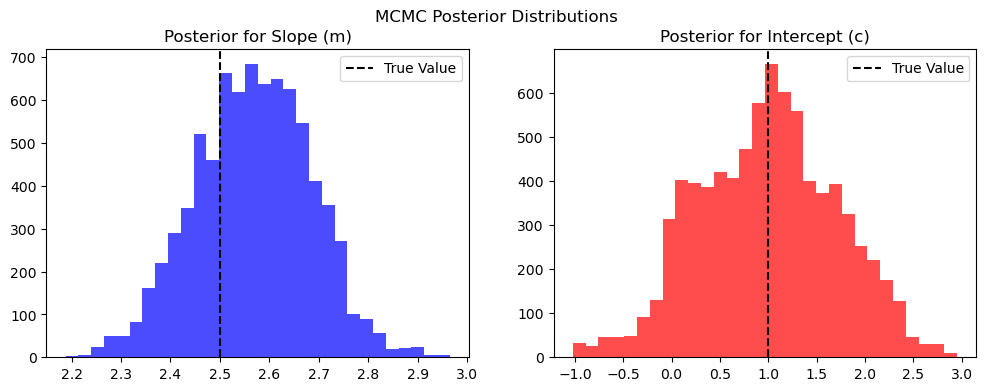

In [3]:
def section_6_mcmc_uncertainties():
    """
    Illustrates Section 6: Using a basic Metropolis-Hastings MCMC random walk 
    to sample the posterior distribution of a simple model (y = mx + c) and map uncertainties.
    """
    print("--- Section 6: MCMC for Posterior Sampling ---")
    
    # Data generation
    x = np.linspace(0, 10, 20)
    true_m, true_c = 2.5, 1.0
    yerr = 1.5
    y = true_m * x + true_c + np.random.normal(0, yerr, len(x))
    
    # Define Log-Likelihood (Chi-Square)
    def log_likelihood(theta, x, y, yerr):
        m, c = theta
        model = m * x + c
        chi2 = np.sum(((y - model) / yerr)**2)
        return -0.5 * chi2 # log P ~ -chi^2 / 2
    
    # Metropolis-Hastings setup
    n_steps = 10000
    chain = np.zeros((n_steps, 2))
    current_theta = np.array([0.0, 0.0]) # starting guess
    current_logL = log_likelihood(current_theta, x, y, yerr)
    
    accepted = 0
    for i in range(n_steps):
        # Propose a new step (Gaussian random walk)
        proposal = current_theta + np.random.normal(0, 0.1, 2)
        proposal_logL = log_likelihood(proposal, x, y, yerr)
        
        # Acceptance probability
        log_accept_ratio = proposal_logL - current_logL
        
        # Metropolis acceptance rule
        if np.log(np.random.uniform(0, 1)) < log_accept_ratio:
            current_theta = proposal
            current_logL = proposal_logL
            accepted += 1
            
        chain[i] = current_theta
        
    print(f"MCMC Acceptance rate: {accepted/n_steps * 100:.1f}%")
    
    # Discard burn-in (first 20% of the chain)
    burnin = int(0.2 * n_steps)
    samples = chain[burnin:]
    
    m_est, c_est = np.mean(samples, axis=0)
    m_err, c_err = np.std(samples, axis=0)
    
    print(f"MCMC Slope (m): {m_est:.3f} +/- {m_err:.3f}")
    print(f"MCMC Intercept (c): {c_est:.3f} +/- {c_err:.3f}\n")
    
    # Plotting histograms
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(samples[:, 0], bins=30, color='b', alpha=0.7)
    ax1.axvline(true_m, color='k', linestyle='--', label='True Value')
    ax1.set_title("Posterior for Slope (m)")
    ax1.legend()
    
    ax2.hist(samples[:, 1], bins=30, color='r', alpha=0.7)
    ax2.axvline(true_c, color='k', linestyle='--', label='True Value')
    ax2.set_title("Posterior for Intercept (c)")
    ax2.legend()
    plt.suptitle("MCMC Posterior Distributions")
    plt.show()

section_6_mcmc_uncertainties()

## 7. Robust Estimation: Dealing with Reality

Throughout this chapter, we have worshipped at the altar of $\chi^2$. As stated in Section 2, least squares is rooted in the assumption that measurement errors are normally distributed.

What happens when this is not true? What if your equipment occasionally misfires, or a cosmic ray hits your CCD detector, producing a data point that is 10 standard deviations away from the true curve?

In a Gaussian distribution, the probability of a $10\sigma$ event is roughly $10^{-23}$. If you are doing least squares, the mathematics fiercely forces the curve to try and accommodate that outlier, because squaring a distance of $10\sigma$ yields a massive penalty of 100 in the $\chi^2$ sum. The curve will twist and contort itself to minimize that squared penalty, utterly ruining the fit for the rest of the good data.

The "breakdown point" of least squares is mathematically $1/N$. A single arbitrarily bad data point can pull the entire fit infinitely far away from the true parameters. Least squares is notoriously non-robust.

### 7.1 M-Estimates and Absolute Deviation

To build a robust estimator, we might seem to be abandoning our rigorous statistical framework for a purely phenomenological one, but this is not true. Recall from Section 2 that minimizing $\chi^2 = \sum z_i^2$ is equivalent to maximizing the likelihood of a Gaussian error distribution, where $P \propto \exp(-z^2/2)$. By replacing $\chi^2$ with a different loss function $\rho(z)$ that grows less rapidly than $z^2$ for large deviations, we are simply asserting a different, more "fat-tailed" prior probability distribution for our measurement errors, specifically $P(z) \propto \exp(-\rho(z))$. Here, we define $z_i \equiv (y_i - y(x_i)) / \sigma_i$.

The most obvious alternative is to minimize the sum of the absolute deviations (the $L_1$ norm):

$$\sum_{i=1}^{N} \left| \frac{y_i - y(x_i)}{\sigma_i} \right| \quad \mathrm{i.e.,} \quad \rho(z) = |z|$$

Probabilistically, minimizing the $L_1$ norm is equivalent to assuming the measurement errors follow a Laplace distribution (a double exponential), $P(z) \propto \exp(-|z|)$. This distribution has significantly wider tails than a Gaussian, making it vastly more robust than least squares. An outlier with $z = 10$ only contributes a penalty of 10, not 100. However, the absolute value function has a discontinuous derivative at zero, making it annoying to minimize using gradient-based methods like Levenberg-Marquardt.

A better approach is an M-estimate (Maximum-likelihood type estimate). We design a loss function that looks like a parabola near the origin (for Gaussian noise) but flattens out for large deviations.

A popular choice is the Huber loss function:

$$\rho(z) = 
\begin{cases} 
\frac{1}{2}z^2 & \mathrm{for\ } |z| \le c \\
c|z| - \frac{1}{2}c^2 & \mathrm{for\ } |z| > c 
\end{cases}$$

where $c$ is a tuning constant, typically around 1.345. Probabilistically, this corresponds to an error distribution that is Gaussian in its core but transitions smoothly to a Laplace distribution in its tails, which gives 95% efficiency for purely Gaussian data but protects against outliers.

An even more aggressive choice, if you expect severe outliers, is to model the errors using a Cauchy distribution (often called a Lorentzian profile in physics). Probabilistically, $P(z) \propto \exp(-\log(1+z^2/2)) \propto (1+z^2/2)^{-1}$. This distribution has such catastrophically heavy tails that its variance is mathematically undefined, meaning it completely expects extreme outliers as a normal consequence of the data generating process:

$$\rho(z) = \log(1 + \frac{1}{2}z^2)$$

Taking the derivative to find the equivalent to our normal equations yields a weighting function $\psi(z) = \rho^\prime(z) = \frac{z}{1 + z^2/2}$. Notice that for large $z$, the weight actually decreases back towards zero. The fit mathematically ignores data points that are too far away.

### 7.2 Iteratively Reweighted Least Squares (IRLS)

How do we solve these non-linear robust problems? We use a beautiful trick called Iteratively Reweighted Least Squares.

We want to solve $\sum_{i} \psi(z_i) \frac{\partial z_i}{\partial a_k} = 0$. We can rewrite this by defining a weight function $w(z_i) \equiv \psi(z_i) / z_i$. The equations become:

$$\sum_{i=1}^{N} w(z_i) z_i \frac{\partial z_i}{\partial a_k} = 0$$

This looks exactly like the standard least squares equations, but each data point has an extra weight $w(z_i)$ that depends on the residual $z_i$.

The algorithm is:

1. Perform a standard least squares fit to get initial parameter guesses $\mathbf{a}$.

1. Calculate the residuals $z_i$ for all data points.

1. Calculate the robust weights $w(z_i)$ for each data point based on your chosen loss function.

1. Perform a weighted least squares fit using these weights to find new parameters.

1. Iterate steps 2-4 until convergence.

If a point is an outlier, its residual $z_i$ will be large. In the next iteration, its weight $w(z_i)$ will be tiny, effectively removing it from the matrix equations. IRLS allows you to use your highly optimized Levenberg-Marquardt or SVD routines to perform robust fitting simply by updating the error bars $\sigma_i \to \sigma_i / \sqrt{w(z_i)}$ at each step.

--- Section 7: Robust Estimation (IRLS) ---
True Parameters:     m=2.00, c=5.00
Standard LS Fit:     m=2.52, c=3.69 (Corrupted)
Robust IRLS Fit:     m=2.09, c=4.38 (Recovered)



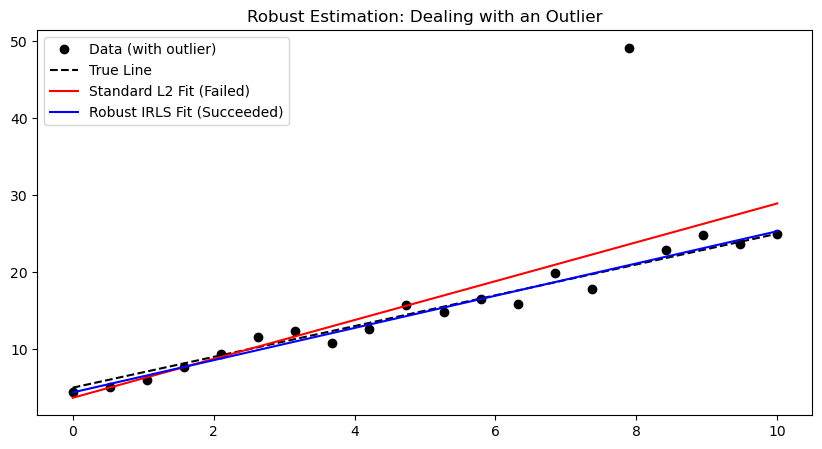

In [4]:
def section_7_irls_robust_fitting():
    """
    Illustrates Section 7: Dealing with extreme outliers using 
    Iteratively Reweighted Least Squares (IRLS) with a Cauchy/Lorentzian loss function.
    """
    print("--- Section 7: Robust Estimation (IRLS) ---")
    
    x = np.linspace(0, 10, 20)
    true_m, true_c = 2.0, 5.0
    y = true_m * x + true_c + np.random.normal(0, 1.0, len(x))
    
    # Add a massive, 30-sigma outlier
    y[15] += 30.0 
    
    # 1. Standard Least Squares (Vulnerable)
    A = np.vstack([x, np.ones(len(x))]).T
    standard_fit, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    
    # 2. IRLS with Cauchy Loss Function
    # Weight w(z) = 1 / (1 + z^2/2)
    theta_irls = standard_fit.copy() # start with least squares guess
    
    iterations = 10
    for i in range(iterations):
        model = A @ theta_irls
        residuals = y - model
        # Standardize residuals (assuming sigma=1 for simplicity)
        z = residuals / 1.0 
        
        # Calculate Cauchy weights
        weights = 1.0 / (1.0 + 0.5 * z**2)
        W = np.diag(weights)
        
        # Weighted least squares: theta = (A^T W A)^-1 A^T W y
        AT_W_A = A.T @ W @ A
        AT_W_y = A.T @ W @ y
        theta_irls = np.linalg.solve(AT_W_A, AT_W_y)
        
    print(f"True Parameters:     m={true_m:.2f}, c={true_c:.2f}")
    print(f"Standard LS Fit:     m={standard_fit[0]:.2f}, c={standard_fit[1]:.2f} (Corrupted)")
    print(f"Robust IRLS Fit:     m={theta_irls[0]:.2f}, c={theta_irls[1]:.2f} (Recovered)\n")

    plt.figure(figsize=(10, 5))
    plt.plot(x, y, 'ko', label='Data (with outlier)')
    plt.plot(x, true_m * x + true_c, 'k--', label='True Line')
    plt.plot(x, A @ standard_fit, 'r-', label='Standard L2 Fit (Failed)')
    plt.plot(x, A @ theta_irls, 'b-', label='Robust IRLS Fit (Succeeded)')
    plt.title("Robust Estimation: Dealing with an Outlier")
    plt.legend()
    plt.show()


section_7_irls_robust_fitting()

## 8. Conclusion

Data fitting is a foundational tool of computational science, but it demands respect. Never blindly invert an $\mathbf{A}^T\mathbf{A}$ matrix; SVD is your shield against numerical singularity. When navigating the treacherous topology of nonlinear $\chi^2$ surfaces, Levenberg-Marquardt is your most reliable guide. And finally, always look at your residuals. If a $10\sigma$ outlier is staring back at you, put down the Gaussian $\chi^2$ and pick up an M-estimator. A good numerical scientist trusts the algorithm, but verifies with a plot.